In [1]:
import os
import sys
sys.path.append('/discover/nobackup/caturne4/AeroApps/Python') # changes python path to allow for pyobs import
import numpy as np
import pandas as pd
import xarray as xr
from datetime import datetime, timedelta
import warnings
import multiprocessing as mp
from functools import partial
import time
from pyobs.aeronet import AERONET_L2, VARS 
import yaml
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')
import cartopy.feature as cfeature

In [2]:
def parse_aeronet_daily_file(filepath, start_date, end_date):
    """Reads a daily global AERONET file using AERONET_L2 class, applies QC, and returns hourly means per station."""
    try:
        custom_vars = list(VARS) + ['440_870_Angstrom_Exponent']
         
        aero = AERONET_L2(filepath, version=3, Vars=custom_vars, Verbose=False)
     
        if aero.nobs == 0:
            return None, "No data loaded"
        
        df = pd.DataFrame({               # creating dataframe from aeronet data
            'DateTime': aero.tyme,
            'lats': aero.Latitude,
            'lons': aero.Longitude,
            'station': aero.Location, 
            'aod_550': aero.AOT_550,
            'angstrom': getattr(aero, '440_870_Angstrom_Exponent', np.nan) 
        })

        # subsetting to start and end dates
        df = df[(df['DateTime'] >= start_date) & (df['DateTime'] <= end_date)] 
        if df.empty: 
            return None, "No data in specified date range"


        # cleaning the data
        df.replace(-999.0, np.nan, inplace=True)

        df.loc[(df['aod_550'] < 0) | (df['aod_550'] >= 10), 'aod_550'] = np.nan 

        valid_mask_870 = (df['angstrom'] >= -1) & (df['angstrom'] <= 3)
        df.loc[~valid_mask_870, 'angstrom'] = np.nan

        df = df.dropna(subset=['aod_550', 'angstrom'])

        if df.empty:
            return None, "No valid paired AOD/Angstrom data after QC"

        # organizing the data
        df['obs hour'] = df['DateTime'].dt.floor('h')
        
        hourly = df.groupby(['station', 'obs hour']).agg({
            'aod_550': 'mean', 
            'angstrom': 'mean',
            'lats': 'first',
            'lons': 'first'
        }).reset_index()

        hourly= hourly[hourly['station'].isin(stations)]
        
        return hourly, "Success"
        
    except ValueError as e:
        return None, f"Parsing Error: {str(e)}"
    except Exception as e:
        return None, f"Exception test: {type(e).__name__} - {str(e)}"

In [3]:
import glob
import xarray as xr
import pandas as pd
import numpy as np

def extract_model_time(obs_time, stations_dict, base_dir):
    """Worker function to process a single observation time."""
    obs_time = pd.to_datetime(obs_time)
    valid_YYYYMMDD = obs_time.strftime('%Y%m%d')
    valid_HHmm = obs_time.strftime('%H00')
    
    file_pattern = f"{base_dir}/CYCLED_REPLAY_P10800_C21600_T21600_*/GEOS.hwt_15mn_slv_LCC.{valid_YYYYMMDD}_{valid_HHmm}z.nc4"
    model_files = glob.glob(file_pattern)
    
    if not model_files:
        return None

    ds = xr.open_mfdataset(model_files, combine='nested', concat_dim='forecast_run',
                           parallel=False, compat = 'override', coords = 'minimal')

    
    lats_da = xr.DataArray(stations_dict['lats'], dims='station')
    lons_da = xr.DataArray(stations_dict['lons'], dims='station')

    
    results = []
    
    
    for stat_name, target_lat, target_lon in zip(stations_dict['names'], lats_da.values, lons_da.values):

        lon_diff = (ds['lons'] - target_lon + 180) %360 -180
        

        dist = (ds['lats'] - target_lat)**2 + lon_diff**2
        nearest_point = dist.compute().argmin(dim=['Xdim', 'Ydim'])
        

        bc_pts = ds['BCEXTTAU'].isel(nearest_point)
        br_pts = ds['BREXTTAU'].isel(nearest_point)
        du_pts = ds['DUEXTTAU'].isel(nearest_point)
        ni_pts = ds['NIEXTTAU'].isel(nearest_point)
        oc_pts = ds['OCEXTTAU'].isel(nearest_point)
        ss_pts = ds['SSEXTTAU'].isel(nearest_point)
        su_pts = ds['SUEXTTAU'].isel(nearest_point)
        tot_pts = ds['TOTEXTTAU'].isel(nearest_point)

        if 'forecast_run' in bc_pts.dims:
            bc_val = bc_pts.mean(dim='forecast_run').squeeze().values.flatten()[0]
            br_val = br_pts.mean(dim='forecast_run').squeeze().values.flatten()[0]
            du_val = du_pts.mean(dim='forecast_run').squeeze().values.flatten()[0]
            ni_val = ni_pts.mean(dim='forecast_run').squeeze().values.flatten()[0]
            oc_val = oc_pts.mean(dim='forecast_run').squeeze().values.flatten()[0]
            ss_val = ss_pts.mean(dim='forecast_run').squeeze().values.flatten()[0]
            su_val = su_pts.mean(dim='forecast_run').squeeze().values.flatten()[0]
            tot_val = tot_pts.mean(dim='forecast_run').squeeze().values.flatten()[0]
        else:
            bc_val = bc_pts.squeeze().values.flatten()[0]
            br_val = br_pts.squeeze().values.flatten()[0]
            du_val = du_pts.squeeze().values.flatten()[0]
            ni_val = ni_pts.squeeze().values.flatten()[0]
            oc_val = oc_pts.squeeze().values.flatten()[0]
            ss_val = ss_pts.squeeze().values.flatten()[0]
            su_val = su_pts.squeeze().values.flatten()[0]
            tot_val = tot_pts.squeeze().values.flatten()[0]
            

        results.append({
            'obs hour': obs_time,
            'station': stat_name,
            'model_bc_aod': float(bc_val),
            'model_br_aod': float(br_val),
            'model_du_aod': float(du_val),
            'model_ni_aod': float(ni_val),
            'model_oc_aod': float(oc_val),
            'model_ss_aod': float(ss_val),
            'model_su_aod': float(su_val),
            'model_tot_aod': float(tot_val)
        })
    

    return results

In [4]:
from functools import partial
import multiprocessing as mp

def get_modeled_aod_fast(obs_df):
    print("Extracting modeled AOD using multiprocessing...")
    
    unique_obs_times = obs_df['obs hour'].unique()
    stations_df = obs_df[['station', 'lats', 'lons']].drop_duplicates()

    stations_dict = {
        'names': stations_df['station'].values,
        'lats': stations_df['lats'].values,
        'lons': stations_df['lons'].values
    }
    base_dir = "/discover/nobackup/projects/gmao/osse2/HWT/CONUS02KM/Feature-c2160_L137/forecasts"
    
    worker_func = partial(extract_model_time, stations_dict=stations_dict, base_dir=base_dir)
    
    n_procs = max(1, mp.cpu_count() - 1)
    extracted_data = []
    with mp.Pool(n_procs) as pool:
        for result in pool.imap_unordered(worker_func, unique_obs_times):
            if result is not None:
                extracted_data.extend(result)
    print('All model data extracted')
    model_df = pd.DataFrame(extracted_data)

    if model_df.empty:
        print("Warning: No modeled data successfully extracted.")
        return obs_df
        
    merged_df = pd.merge(
        obs_df.drop(columns=['model_aod'], errors='ignore'), 
        model_df, 
        on=['obs hour', 'station'], 
        how='left'
    )
    print(merged_df)
    return merged_df

In [5]:
import os
import xarray as xr
import pandas as pd
import numpy as np
from functools import partial
import multiprocessing as mp

def get_analysis_aod_fast(obs_df):
    print("Extracting analysis AOD using multiprocessing...")
    
    unique_obs_times = obs_df['obs hour'].unique()
    stations_df = obs_df[['station', 'lats', 'lons']].drop_duplicates()
    
    stations_dict = {
        'names': stations_df['station'].values,
        'lats': stations_df['lats'].values,
        'lons': stations_df['lons'].values
    }
    
    worker_func = partial(extract_analysis_time, stations_dict=stations_dict)
    
    n_procs = max(1, mp.cpu_count() - 1)
    extracted_data = []
    
    with mp.Pool(n_procs) as pool:
        for result in pool.imap_unordered(worker_func, unique_obs_times):
            if result is not None:
                extracted_data.extend(result)
                
    analysis_df = pd.DataFrame(extracted_data)
    
    if analysis_df.empty:
        print("Warning: No analysis data successfully extracted.")
        return obs_df
        
    cols_to_drop = [
        'analysis_bc_aod', 'analysis_br_aod', 'analysis_du_aod', 
        'analysis_ni_aod', 'analysis_oc_aod', 'analysis_ss_aod', 'analysis_su_aod'
    ]

    merged_df = pd.merge(
        obs_df.drop(columns=cols_to_drop, errors='ignore'), 
        analysis_df, 
        on=['obs hour', 'station'], 
        how='left'
    )
    
    return merged_df


def extract_analysis_time(obs_time, stations_dict):
    """Worker function to process a single observation time for GEOS-FP Analysis."""
    obs_time = pd.to_datetime(obs_time)
    
    YYYY = obs_time.strftime('%Y')
    MM = obs_time.strftime('%m')
    YYYYMMDD = obs_time.strftime('%Y%m%d')
    HH = obs_time.strftime('%H')
    
    file_path = f"/discover/nobackup/projects/gmao/geos_fp_arch/f5430_fp/chem/Y{YYYY}/M{MM}/f5430_fp.inst1_2d_hwl_Nx.{YYYYMMDD}_{HH}00z.nc4"
    
    if not os.path.exists(file_path):
        print(f'Could not find analysis file: {file_path}')
        return None
        
    try:

        ds = xr.open_dataset(file_path)

        lats_da = xr.DataArray(stations_dict['lats'], dims='station')
        lons_da = xr.DataArray(stations_dict['lons'], dims='station')
        

        bc_pts = ds['BCEXTTAU'].sel(lat=lats_da, lon=lons_da, method='nearest')
        br_pts = ds['BREXTTAU'].sel(lat=lats_da, lon=lons_da, method='nearest')
        du_pts = ds['DUEXTTAU'].sel(lat=lats_da, lon=lons_da, method='nearest')
        ni_pts = ds['NIEXTTAU'].sel(lat=lats_da, lon=lons_da, method='nearest')
        oc_pts = ds['OCEXTTAU'].sel(lat=lats_da, lon=lons_da, method='nearest')
        ss_pts = ds['SSEXTTAU'].sel(lat=lats_da, lon=lons_da, method='nearest')
        su_pts = ds['SUEXTTAU'].sel(lat=lats_da, lon=lons_da, method='nearest')
        tot_pts = ds['TOTEXTTAU'].sel(lat=lats_da, lon=lons_da, method='nearest')

        bc_val = bc_pts.squeeze().values.flatten()
        br_val = br_pts.squeeze().values.flatten()
        du_val = du_pts.squeeze().values.flatten()
        ni_val = ni_pts.squeeze().values.flatten()
        oc_val = oc_pts.squeeze().values.flatten()
        ss_val = ss_pts.squeeze().values.flatten()
        su_val = su_pts.squeeze().values.flatten()
        tot_val = tot_pts.squeeze().values.flatten()
            
        results = []
        for i, stat_name in enumerate(stations_dict['names']):
            results.append({
                'obs hour': obs_time,
                'station': stat_name,
                'analysis_bc_aod': bc_val[i],
                'analysis_br_aod': br_val[i],
                'analysis_du_aod': du_val[i],
                'analysis_ni_aod': ni_val[i],
                'analysis_oc_aod': oc_val[i],
                'analysis_ss_aod': ss_val[i],
                'analysis_su_aod': su_val[i],
                'analysis_tot_aod': tot_val[i]
            })
            
        ds.close()
        return results

    except Exception as e:
        print(f'Failed to get data for {obs_time}\n', e)
        return None

In [6]:
def main(start_date, end_date, base_path, experiment_name, output_dir="./aeronet_model_comparison/", min_points=30, ts_freq='none'):
    
    start_time = time.time()
    start_day = datetime.strftime(start_date, '%Y%m%d')
    start_hour = datetime.strftime(start_date, '%H')
    n_procs = max(1, mp.cpu_count() - 1)
    model_path_template = config['paths']['model1']
    aeronet_dir_base = config['paths']['observations']
    analysis_path_template = config['paths']['model2']
    file_comparison = 'aeronet' # file_comparison used for output file names



    
    print(f" Locating AERONET daily files between {start_date.strftime('%Y-%m-%d')} and {end_date.strftime('%Y-%m-%d')}...")
    
    files = []
    current_date = start_date.replace(hour=0, minute=0, second=0)

    ############################
    ### Processing aeronet files
    ############################

    while current_date <= end_date:
        YYYY = current_date.strftime('%Y') # setting date variables
        MM = current_date.strftime('%m')
        YYYYMMDD = current_date.strftime('%Y%m%d')
        
        #Aeronet switches filename formats in 2024!
        possible_filenames = [
            f"aeronet_v30.{YYYYMMDD}.txt",
            f"aeronet_v3.aod.{YYYYMMDD}.txt"
        ]
        
        for fname in possible_filenames:
            file_path = f"{aeronet_dir_base}/Y{YYYY}/M{MM}/{fname}"
            
            if os.path.exists(file_path):
                files.append(file_path)
                break 
        
        current_date += timedelta(days=1)
    
    if not files:
        print(f"No AERONET files found in the specified date range at {aeronet_dir_base}!")
        return
        
    print(f"Found {len(files)} daily AERONET files. Parsing...")
        
    parse_func = partial(parse_aeronet_daily_file, start_date=start_date, end_date=end_date)
    dfs = []
    error_counts = {}

    with mp.Pool(n_procs) as pool:
        for df, msg in pool.imap_unordered(parse_func, files):
            if df is not None:
                dfs.append(df)
            else:
                print(msg)
                error_counts[msg] = error_counts.get(msg, 0) + 1

    print("\n--- AERONET Parse Summary ---")
    print(f"Successfully loaded {len(dfs)} days of data.")
    
    if error_counts:
        print("\nReasons for skipped files:")
        for reason, count in sorted(error_counts.items(), key=lambda x: x[1], reverse=True):
            print(f"  - {reason}: {count} files")
            
    if not dfs:
        print("\nNo data to process. Exiting.")
        return
        
    master_df = pd.concat(dfs, ignore_index=True)
    master_df['obs date'] = master_df['obs hour'].dt.floor('D')
    print(f"\nTotal valid AERONET hours across all stations: {len(master_df)}")

    master_df = get_modeled_aod_fast(master_df)
    print('Merged df returned')

    master_df = get_analysis_aod_fast(master_df)

    print(master_df)
    print(f"\nSampling {experiment_name}...")
    
    

    grouped = [(date, group) for date, group in master_df.groupby('obs date')]
    
    # print(grouped)

    print('Finished Running')
    return master_df

In [11]:
with open('config.yaml', 'r') as file:
        config = yaml.safe_load(file)
start_date = datetime.strptime(config['dates']['start'], '%Y-%m-%d %H:%M:%S') 
end_date = datetime.strptime(config['dates']['end'], '%Y-%m-%d %H:%M:%S') 

base_path = config['paths']['base']
experiment_name = config['paths']['experiment']
output_path = config['paths']['output']
aeronet_path = config['paths']['observations']
forecast_path = config['paths']['model1']

FPanalysis_path = config['paths']['model2']

output_dir = os.path.join(base_path, output_path, experiment_name)
min_points = config['min_station_obs']   # of required hourly data points to be included in high-level stats
ts_freq = config['temporal_res']
evaluation = config['evaluation']
time_step = config['time_step']
stations = ['GSFC', 'NEON_UNDE','Granite_Island','Chiwaukee_Prairie','NPU_Chicago_IL',
            'London-CDN','Egbert','Toronto', 'Dayton', 'East_Brunswick', 'Flushing','UMBC','Billerica']

col_names = ['obs hour','aod_550','angstrom','lats','lons','obs date','model_aod','model_ang',
             'analysis_aod','analysis_ang','initialization time' ,'fcst length']

time_period =  datetime.strptime(config['dates']['end'], '%Y-%m-%d %H:%M:%S') - datetime.strptime(config['dates']['start'],'%Y-%m-%d %H:%M:%S')
time_period = int(time_period.total_seconds())/3600
if timedelta(hours = time_period) < timedelta(hours=int(config['fcst_period'])):
    fcst_period = int(time_period)
else:
    fcst_period = int(config['fcst_period'])


eval_bins = np.arange(0,fcst_period +1, int(config['eval_bins']))

binned_eval = {}
file = f'../case_study/cs_speciation_regional3.csv'
if os.path.exists(file):
    master_df = pd.read_csv(file)
    master_df['obs hour'] = pd.to_datetime(master_df['obs hour'])
    master_df = master_df.sort_values(by = 'obs hour')
    print('Read file')
else:
    print('file did not exist')
    master_df = main(
        start_date=start_date,
        end_date=end_date,
        base_path=base_path,
        experiment_name=experiment_name,
        output_dir=output_dir, 
        min_points=min_points, 
        ts_freq=ts_freq
    )
    
    master_df.to_csv(f'./final_analysis_speciation_{start_date}_{end_date}.csv')
    master_df['obs hour'] = pd.to_datetime(master_df['obs hour'])
    master_df = master_df.sort_values(by = 'obs hour')


Read file


In [58]:
inc = 5 # used to change all fontsizes of figure simultaneously 
def make_species_plot(master_df, stn):
    stn_df = master_df[master_df['station'] == stn]
    fig, axs = plt.subplots(2,1, figsize = (32,17))

    axs[0].plot(stn_df['obs hour'], stn_df['aod_550'], zorder = 100, marker = 'o', color = 'black', label = 'AERONET Obs')
    axs[1].plot(stn_df['obs hour'], stn_df['aod_550'], zorder = 100, marker = 'o', color = 'black')
    
    axs[0].plot(stn_df['obs hour'], stn_df['model_tot_aod'],linestyle = '--', zorder = 100, color = 'black', label = 'GEOS-CAM Total AOD')
    axs[1].plot(stn_df['obs hour'], stn_df['analysis_tot_aod'],linestyle = '-.', zorder = 100, color = 'black', label = 'GEOS-FP Total AOD')
    species = ['bc', 'br', 'du', 'ni', 'oc', 'ss', 'su']
    species_name = ['Black Carbon', 'Brown Carbon', 'Dust', 'Nitrate', 'Organic Carbon', 'Sea Salt', 'Sulfate']
    colors =       ['black',        '#8C510A',      'yellow','#D55E00','#332288',        'skyblue',  '#009E73']
    model_total = 0
    analysis_total = 0
    lat = stn_df['lats'].min()
    lon = stn_df['lons'].min()
    for i in range(len(species)):
        model_col = f'model_{species[i]}_aod'
        analysis_col = f'analysis_{species[i]}_aod'
    
        # print(model_col)
        model_total += stn_df[model_col]
        analysis_total += stn_df[analysis_col]
        
    
        axs[0].plot(stn_df['obs hour'], model_total, color = colors[i], zorder = -i)
        axs[0].fill_between(stn_df['obs hour'], model_total, color = colors[i], zorder = -i, label = species_name[i])
        axs[0].set_title(f'GEOS-CAM', loc = 'left', fontsize = 28+inc)
        axs[0].set_title(f'Lat: {lat:.2f}, Lon: {lon:.2f}', loc = 'right', fontsize = 22+inc)
        axs[0].set_ylabel('AOD', fontsize = 20+inc)
        axs[0].tick_params(labelsize = 19+inc)
        # axs[0].set_ylim(0, 2.25)
        
        
        
        axs[1].plot(stn_df['obs hour'], analysis_total, color = colors[i], zorder = -i)
        axs[1].fill_between(stn_df['obs hour'], analysis_total, color = colors[i], zorder = -i)
        axs[1].set_title(f'GEOS-FP', loc = 'left', fontsize = 28+inc)
        axs[1].set_title(f'Lat: {lat:.2f}, Lon: {lon:.2f}', loc = 'right', fontsize = 22+inc)
        axs[1].set_xlabel('Dates', fontsize = 20+inc)
        axs[1].set_ylabel('AOD', fontsize = 20+inc)
        axs[1].tick_params(labelsize = 19+inc)

        
    fig.legend(loc = 'lower center', ncols = 5, fontsize = 20+inc)
    fig.autofmt_xdate()
    axs[0].grid()
    axs[1].grid()
    plt.suptitle(f'AOD Speciation - {stn}', fontsize= 30+inc)
    plt.subplots_adjust(hspace = 0.2)
    plt.savefig(f'./speciation/{stn}_{start_date}_{end_date}_speciation.png')

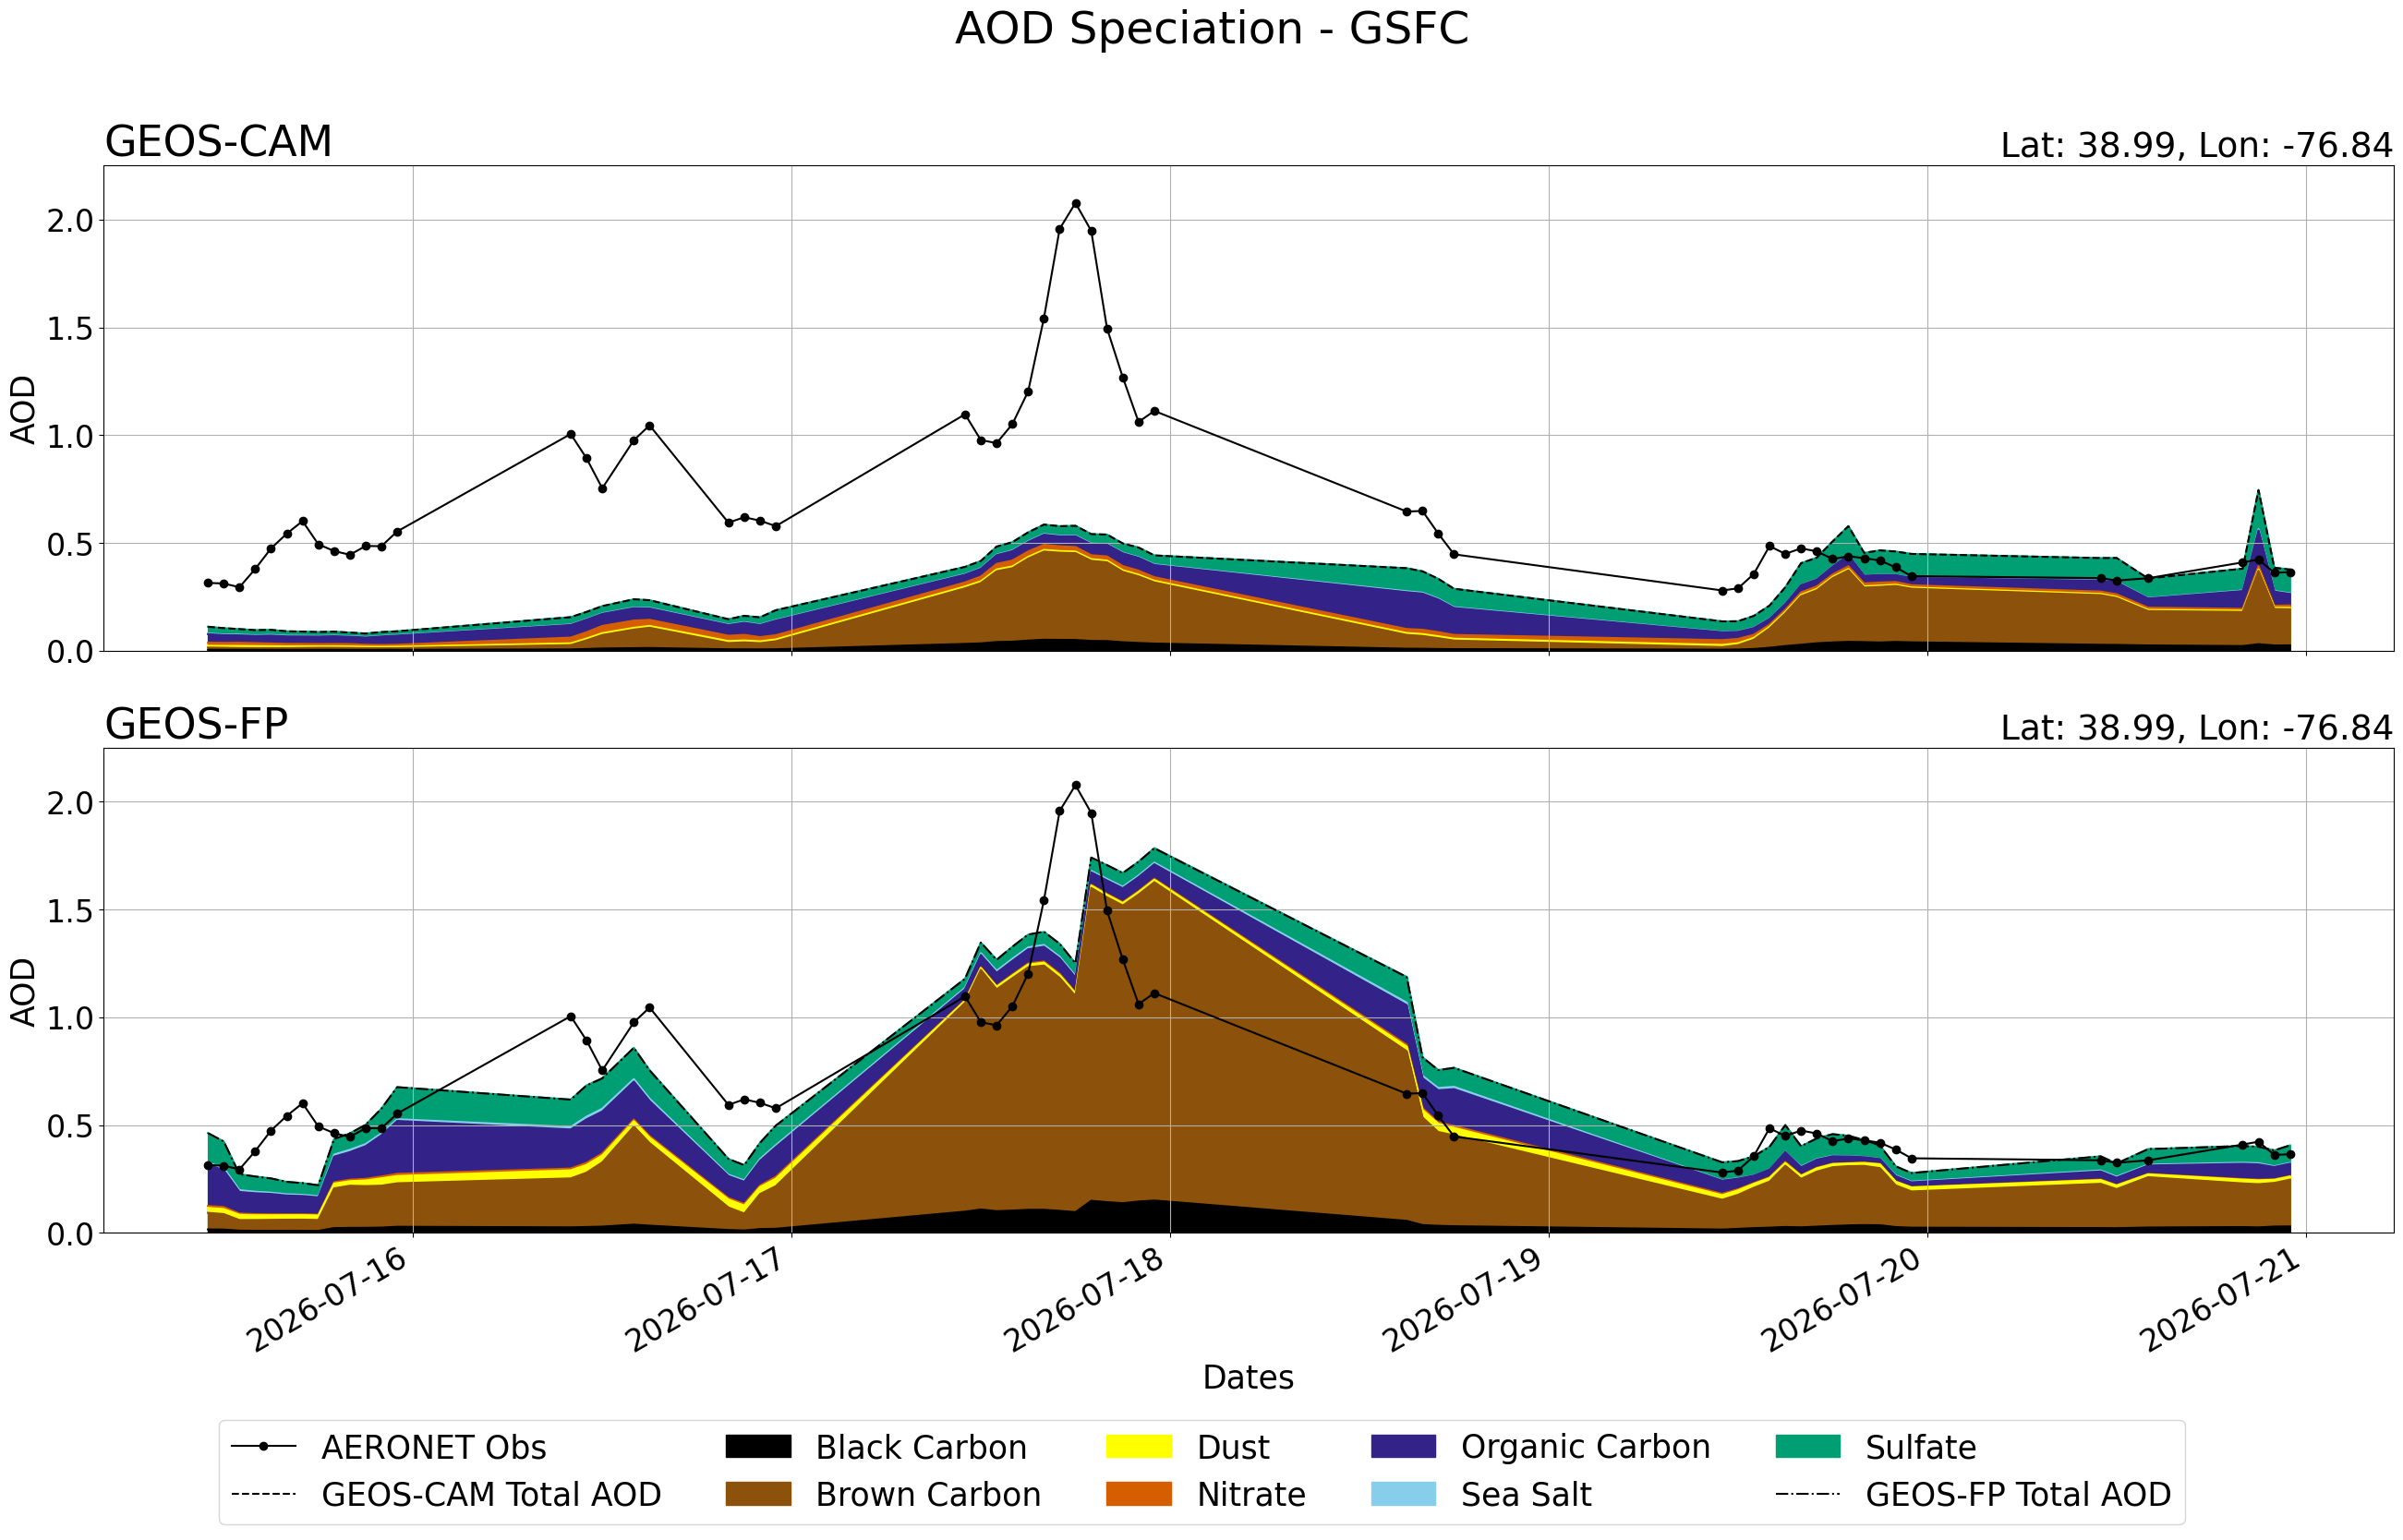

In [56]:
make_species_plot(master_df, 'GSFC')
    

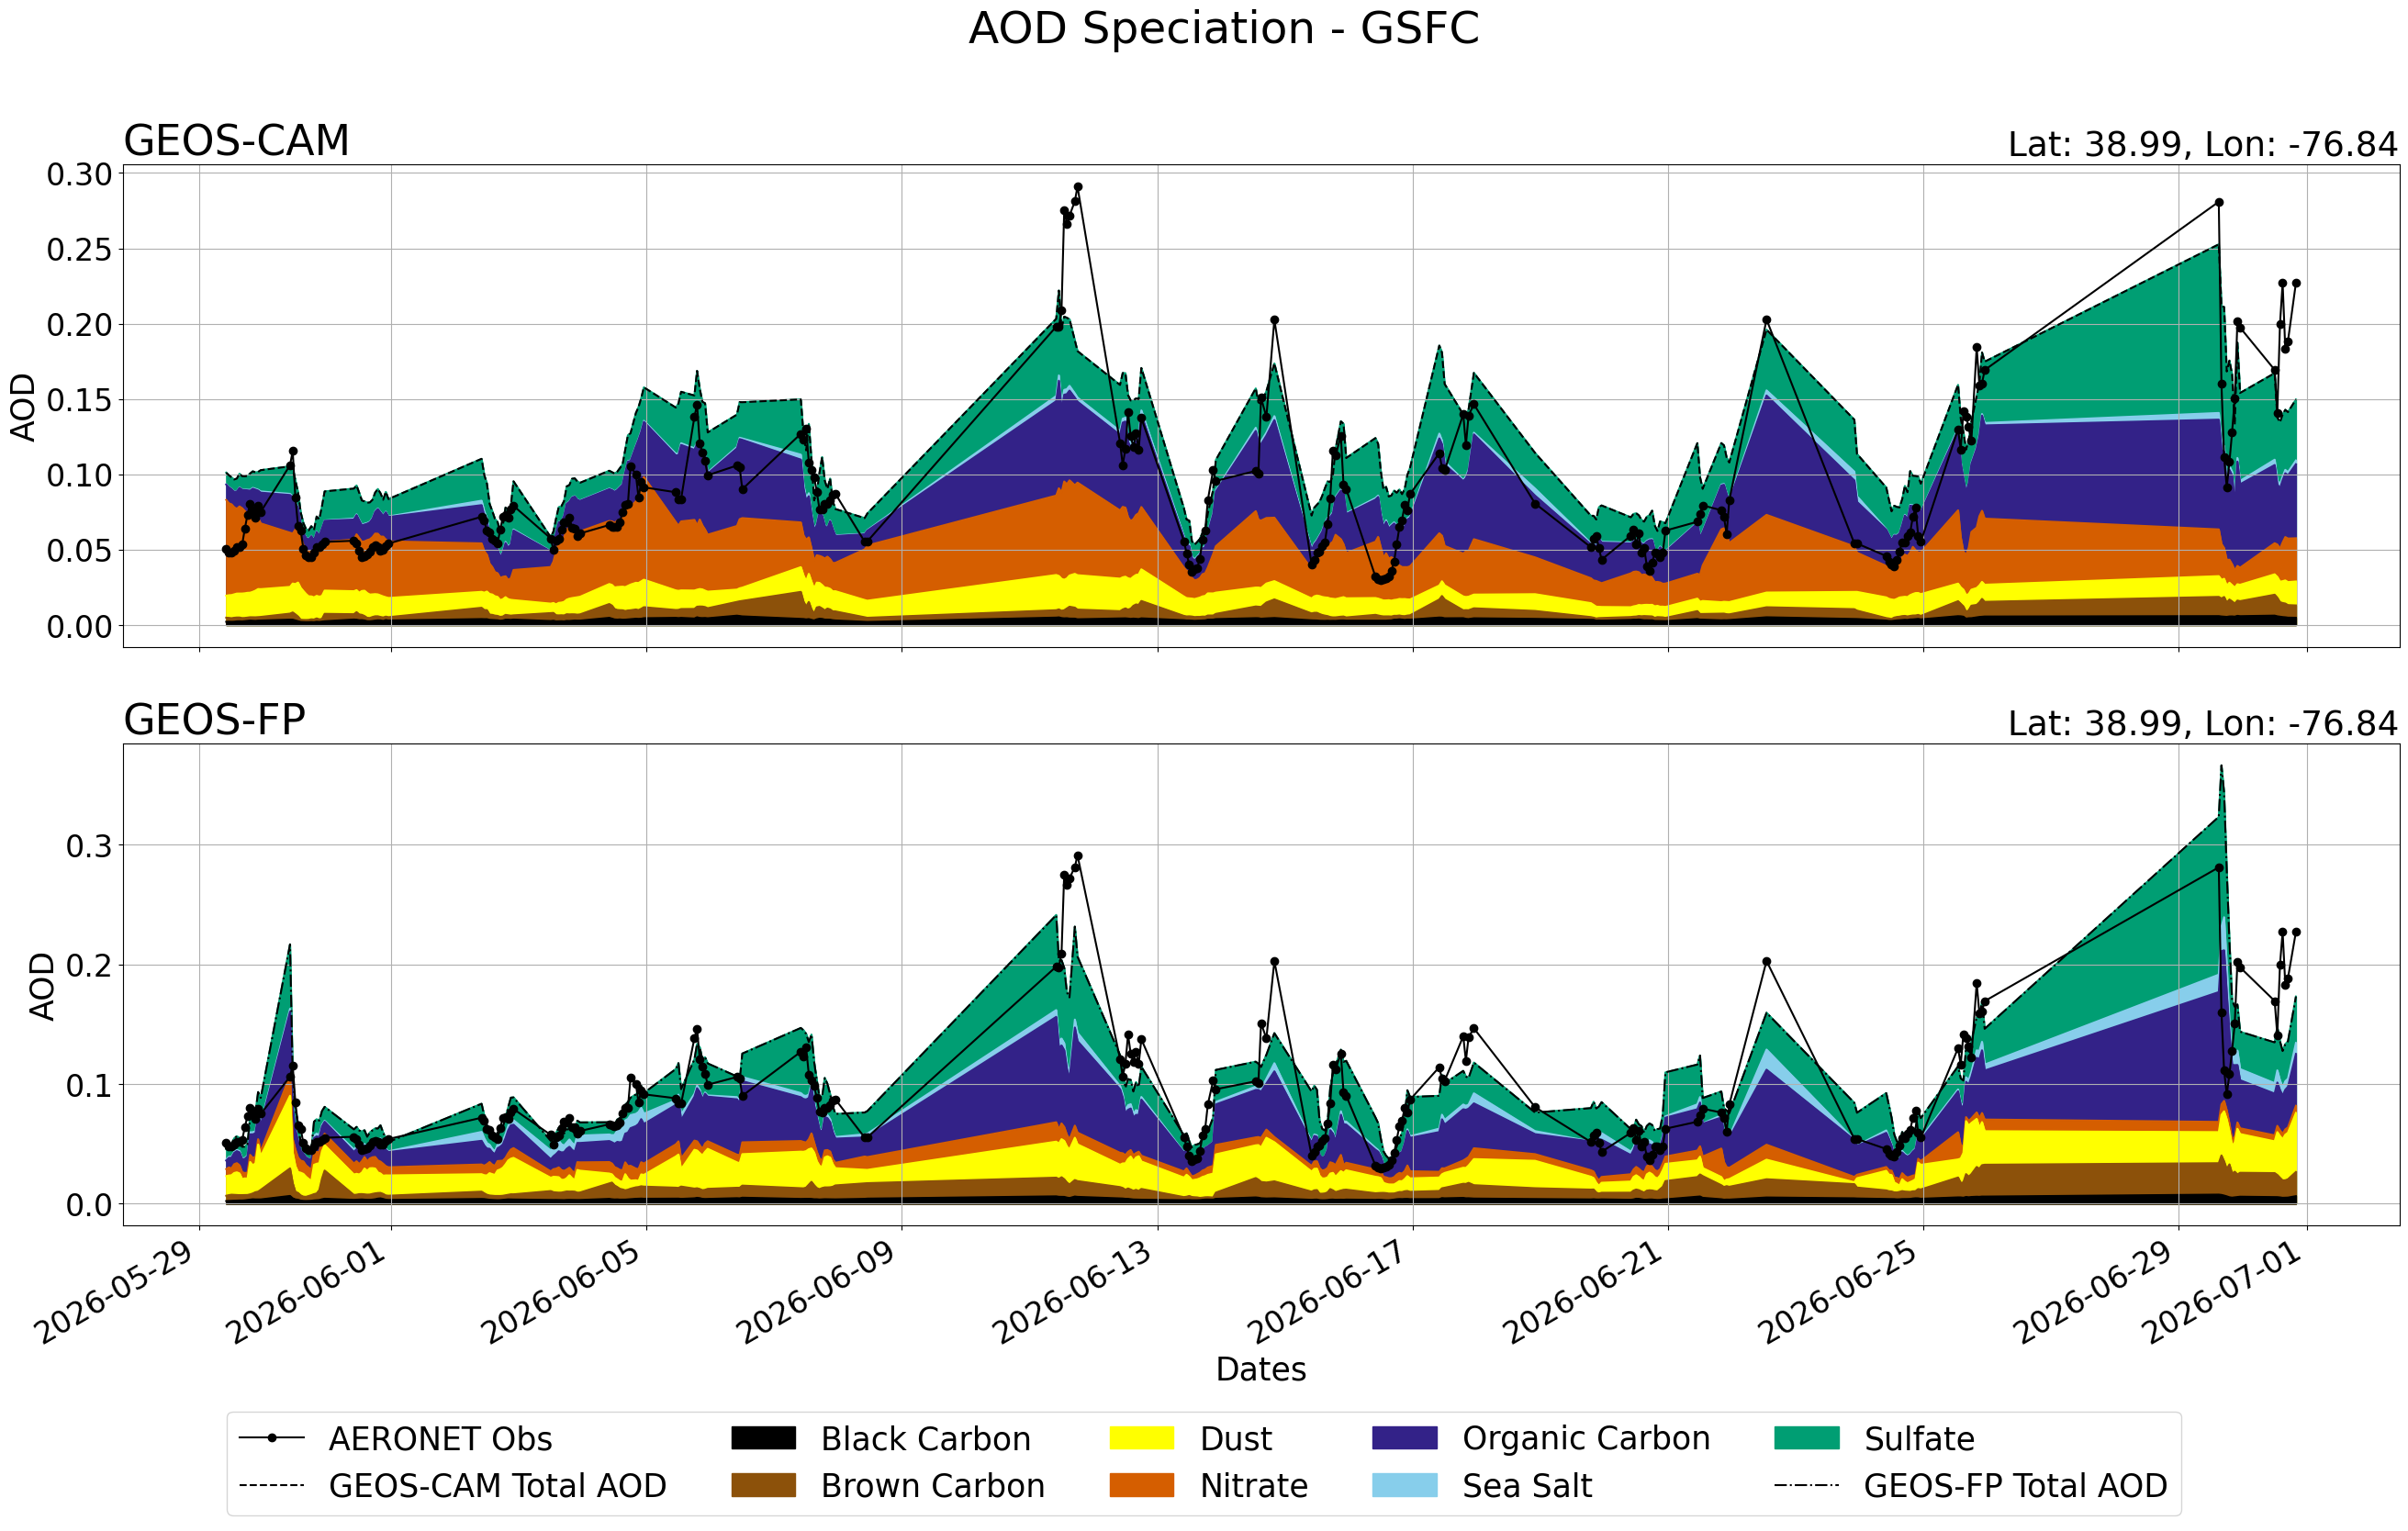

In [59]:
daily_df = pd.read_csv('../case_study/cs_speciation_regional.csv')
daily_df['obs hour'] = pd.to_datetime(daily_df['obs hour'])
daily_df = daily_df.sort_values(by = 'obs hour')
make_species_plot(daily_df, 'GSFC')

619   2026-07-15 00:00:00
566   2026-07-15 00:00:00
638   2026-07-15 00:00:00
597   2026-07-15 00:00:00
629   2026-07-15 00:00:00
              ...        
111   2026-07-20 23:00:00
100   2026-07-20 23:00:00
76    2026-07-20 23:00:00
107   2026-07-20 23:00:00
127   2026-07-20 23:00:00
Name: obs hour, Length: 663, dtype: datetime64[ns]